# HW5 - Fine-Tuning an LLM with LoRA on DialogSum

**Siva Surya Chandran** - sivasurya.chandran@sjsu.edu

For this assignment I fine-tuned `google/flan-t5-base` to summarize conversations, using LoRA through HuggingFace's PEFT library, on the [DialogSum](https://huggingface.co/datasets/neil-code/dialogsum-test) dataset. I ran the model on the same 2 test dialogues before and after fine-tuning to see what changed, and at the end I trained a second adapter with a smaller rank (r=4 vs r=16) to see how much the rank actually matters. That r=4 run is also my second trained model, so I didn't do a separate hyperparameter run.

The assignment says flan-t5-small "or similar". I went with flan-t5-base (about 248M params) because small's summaries were too weak to show a meaningful difference before and after.

Everything below was run top to bottom on a Google Colab T4 GPU.

Sections follow the assignment tasks:
1. Data preparation
2. Baseline inference
3. Apply LoRA
4. Fine-tuning
5. Post-fine-tuning inference
6. Output comparison
7. Experiment: r=4 vs r=16

## Part 0 - Imports and setup

Colab already has `torch`, `transformers` and `datasets`, so this first cell just installs the rest. It also uninstalls `torchao`. Colab comes with an old version of it (0.10), and the newest `peft` refuses to import next to it. I don't use torchao anywhere, so removing it was the easy fix.

I train in regular fp32. T5 models are known to blow up to NaN losses in fp16, and the T4 doesn't support bf16, so fp32 was the safe choice.

In [1]:
%pip install -q peft evaluate rouge_score
!pip uninstall -y torchao

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import os, time, random, json
import numpy as np
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, get_linear_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import evaluate
import transformers, peft

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print("Device:", device)
print("torch", torch.__version__, "| transformers", transformers.__version__, "| peft", peft.__version__)

def free_memory():
    import gc; gc.collect()
    if device == "mps": torch.mps.empty_cache()
    elif device == "cuda": torch.cuda.empty_cache()

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
set_seed(42)

MODEL_NAME = "google/flan-t5-base"
MAX_INPUT_LEN = 512
MAX_TARGET_LEN = 128

Device: cuda
torch 2.11.0+cu128 | transformers 5.16.1 | peft 0.20.0


## Part 1 - Data preparation

Load DialogSum and turn every row into an input/target pair:
- **Input:** the dialogue, with a short instruction in front ("Summarize the following conversation."). FLAN-T5 was instruction-tuned, so it works better when you tell it what task to do.
- **Target:** the human-written summary.

One thing I noticed: the test split has 499 rows but only 167 different dialogues. Every dialogue shows up 3 times (`test_0_1`, `test_0_2`, `test_0_3`), once per human summary. The first time I picked my 2 demo dialogues, I accidentally picked the same conversation twice. So I group the test rows by dialogue, and every test dialogue appears once with its 3 reference summaries.

In [3]:
ds = load_dataset("neil-code/dialogsum-test")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
})


In [4]:
PROMPT = "Summarize the following conversation.\n\n{dialogue}\n\nSummary:"

def to_pair(example):
    return {"input": PROMPT.format(dialogue=example["dialogue"]), "target": example["summary"]}

pairs = ds.map(to_pair, remove_columns=["dialogue", "summary", "topic"])
print(pairs)

# The test split lists each dialogue 3 times (ids test_N_1/2/3), once per human-written reference summary.
# Group them so every unique test dialogue appears once with its 3 references (used for inference + multi-reference ROUGE).
test_groups = {}
for row in pairs["test"]:
    key = row["id"].rsplit("_", 1)[0]
    test_groups.setdefault(key, {"id": key, "input": row["input"], "refs": []})["refs"].append(row["target"])
test_unique = list(test_groups.values())
print(f"test split: {len(pairs['test'])} rows -> {len(test_unique)} unique dialogues")

for i in range(2):
    print(f"==================== processed sample {i} ({pairs['train'][i]['id']}) ====================")
    print("INPUT:\n" + pairs["train"][i]["input"])
    print("\nTARGET:\n" + pairs["train"][i]["target"])
    print()

DatasetDict({
    train: Dataset({
        features: ['id', 'input', 'target'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['id', 'input', 'target'],
        num_rows: 499
    })
    test: Dataset({
        features: ['id', 'input', 'target'],
        num_rows: 499
    })
})
test split: 499 rows -> 167 unique dialogues
==================== processed sample 0 (train_0) ====================
INPUT:
Summarize the following conversation.

#Person1#: Hi, Mr. Smith. I'm Doctor Hawkins. Why are you here today?
#Person2#: I found it would be a good idea to get a check-up.
#Person1#: Yes, well, you haven't had one for 5 years. You should have one every year.
#Person2#: I know. I figure as long as there is nothing wrong, why go see the doctor?
#Person1#: Well, the best way to avoid serious illnesses is to find out about them early. So try to come at least once a year for your own good.
#Person2#: Ok.
#Person1#: Let me see here. Your eyes and ears look fine. Take a d

Next, tokenize. Inputs get cut off at 512 tokens and summaries at 128. Only 45 of the 1,999 training dialogues are long enough to get cut. I pad per batch in the collator, not up to a fixed length, so batches of short dialogues don't waste time on padding.

In [5]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    enc = tokenizer(batch["input"], max_length=MAX_INPUT_LEN, truncation=True)
    enc["labels"] = tokenizer(text_target=batch["target"], max_length=MAX_TARGET_LEN, truncation=True)["input_ids"]
    return enc

tokenized = pairs.map(tokenize, batched=True, remove_columns=["id", "input", "target"])
print(tokenized)

in_lens = [len(x) for x in tokenized["train"]["input_ids"]]
out_lens = [len(x) for x in tokenized["train"]["labels"]]
print(f"input tokens : median {np.median(in_lens):.0f}, max {max(in_lens)}, truncated at 512: {sum(l == MAX_INPUT_LEN for l in in_lens)}")
print(f"target tokens: median {np.median(out_lens):.0f}, max {max(out_lens)}")

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 499
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 499
    })
})
input tokens : median 213, max 512, truncated at 512: 45
target tokens: median 37, max 128


## Part 2 - Baseline inference

Load plain `flan-t5-base` (no fine-tuning) and have it summarize 2 dialogues from the **test** split, `test_0` and `test_1`. The model never sees these during training. I use these same 2 dialogues for every later comparison, and they get saved to `outputs/baseline_outputs.json`.

I use greedy decoding everywhere, so every run gives the same output and the before/after comparisons are fair.

In [6]:
base_model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(device)
base_model.eval()

@torch.no_grad()
def summarize(model, texts, batch_size=8):
    model.eval()
    outs = []
    for i in range(0, len(texts), batch_size):
        enc = tokenizer(texts[i:i + batch_size], max_length=MAX_INPUT_LEN, truncation=True,
                        padding=True, return_tensors="pt").to(device)
        gen = model.generate(**enc, max_new_tokens=MAX_TARGET_LEN, num_beams=1, do_sample=False)
        outs.extend(tokenizer.batch_decode(gen, skip_special_tokens=True))
    free_memory()
    return outs

demo = test_unique[:2]  # test_0 and test_1: two different dialogues
demo_inputs = [d["input"] for d in demo]

baseline_outputs = summarize(base_model, demo_inputs)

os.makedirs("outputs", exist_ok=True)
with open("outputs/baseline_outputs.json", "w") as f:
    json.dump([{"id": d["id"], "references": d["refs"], "baseline": o} for d, o in zip(demo, baseline_outputs)], f, indent=2)

for d, o in zip(demo, baseline_outputs):
    print(f"==================== {d['id']} ====================")
    print(d["input"].split("\n\n")[1])
    print("\nREFERENCE :", d["refs"][0])
    print("BASELINE  :", o)
    print()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


==================== test_0 ====================
#Person1#: Ms. Dawson, I need you to take a dictation for me.
#Person2#: Yes, sir...
#Person1#: This should go out as an intra-office memorandum to all employees by this afternoon. Are you ready?
#Person2#: Yes, sir. Go ahead.
#Person1#: Attention all staff... Effective immediately, all office communications are restricted to email correspondence and official memos. The use of Instant Message programs by employees during working hours is strictly prohibited.
#Person2#: Sir, does this apply to intra-office communications only? Or will it also restrict external communications?
#Person1#: It should apply to all communications, not only in this office between employees, but also any outside communications.
#Person2#: But sir, many employees use Instant Messaging to communicate with their clients.
#Person1#: They will just have to change their communication methods. I don't want any - one using Instant Messaging in this office. It wastes too 

Two examples don't say much on their own, so I also score each model with ROUGE on **all 167 test dialogues**. Each generated summary is compared against all 3 human references, and the `evaluate` ROUGE metric keeps whichever reference matches best.

In [7]:
rouge = evaluate.load("rouge")
eval_inputs = [d["input"] for d in test_unique]
eval_refs = [d["refs"] for d in test_unique]  # list of 3 references per dialogue
N_EVAL = len(eval_inputs)

def rouge_scores(model):
    preds = summarize(model, eval_inputs)
    s = rouge.compute(predictions=preds, references=eval_refs, use_stemmer=True)
    s = {k: round(v * 100, 2) for k, v in s.items()}
    s["avg_words"] = round(float(np.mean([len(p.split()) for p in preds])), 1)
    return s, preds

t0 = time.time()
baseline_rouge, baseline_preds = rouge_scores(base_model)
print(f"Baseline ROUGE on {N_EVAL} test dialogues ({time.time()-t0:.0f}s):", baseline_rouge)
print("Reference summaries avg words:", round(float(np.mean([len(r.split()) for refs in eval_refs for r in refs])), 1))

# done with the untouched base model - free it so it isn't sitting in GPU memory during training
del base_model
free_memory()

Baseline ROUGE on 167 test dialogues (68s): {'rouge1': np.float64(28.37), 'rouge2': np.float64(11.09), 'rougeL': np.float64(24.99), 'rougeLsum': np.float64(24.92), 'avg_words': 15.5}
Reference summaries avg words: 19.3


## Part 3 - Apply LoRA

LoRA keeps all the original weights frozen. For each chosen weight matrix it learns a small low-rank update, $\Delta W = \frac{\alpha}{r} BA$, where $B \in \mathbb{R}^{d \times r}$ and $A \in \mathbb{R}^{r \times k}$. Only $A$ and $B$ get trained, which is a tiny fraction of the model.

My main configuration:

| Setting | Value |
|:--|:--|
| rank `r` | 16 |
| `lora_alpha` | 32 (so alpha/r = 2) |
| `lora_dropout` | 0.05 |
| target modules | `q`, `v` (query and value projections in every attention block, encoder and decoder) |
| task type | `SEQ_2_SEQ_LM` |

For the rank experiment in Part 7, I keep **alpha/r fixed at 2**, so r=4 gets alpha=8. If I left alpha at 32 for both, the r=4 updates would get scaled 4x more than the r=16 ones. Then I'd be changing the effective learning rate along with the rank, and I couldn't tell which one caused a difference.

In [8]:
def make_lora_model(r):
    set_seed(42)  # same LoRA init for each run
    base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    cfg = LoraConfig(
        r=r,
        lora_alpha=2 * r,
        lora_dropout=0.05,
        target_modules=["q", "v"],
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
    )
    return get_peft_model(base, cfg).to(device)

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

lora16 = make_lora_model(r=16)
print(lora16.peft_config["default"])
total, trainable = count_params(lora16)
print(f"\nTotal parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")
print(f"Trainable %          : {100 * trainable / total:.4f}%")
lora16.print_trainable_parameters()

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


LoraConfig(task_type=<TaskType.SEQ_2_SEQ_LM: 'SEQ_2_SEQ_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path='google/flan-t5-base', revision=None, inference_mode=False, r=16, target_modules={'q', 'v'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)

Total parameters     : 249,3

In [9]:
# confirm the adapters are actually attached: show one wrapped layer
print(lora16.base_model.model.encoder.block[0].layer[0].SelfAttention.q)

lora.Linear(
  (base_layer): Linear(in_features=768, out_features=768, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=768, out_features=16, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=16, out_features=768, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)


## Part 4 - Fine-tuning

Just a plain PyTorch training loop on the **full** training split (1,999 dialogues):
- AdamW with lr 1e-3, 5% warmup, then linear decay to 0. LoRA usually wants a higher learning rate than full fine-tuning because it updates so few weights.
- Effective batch size 8, done as micro-batches of 4 with 2 gradient-accumulation steps. I first tried running this on my Mac (16 GB of RAM shared with the GPU), and batches of 8 filled up the memory. The T4 could handle 8 at once, but I kept the same setup so the numbers match.
- 3 epochs, which is 750 optimizer steps.
- Training loss printed every 25 steps, validation loss after every epoch.

In [10]:
collator = DataCollatorForSeq2Seq(tokenizer, label_pad_token_id=-100)  # -100 = ignored by the loss

EPOCHS, MICRO_BATCH, ACCUM, LR, LOG_EVERY = 3, 4, 2, 1e-3, 25  # effective batch = 4 * 2 = 8

@torch.no_grad()
def val_loss(model, loader):
    model.eval()
    losses = [model(**{k: v.to(device) for k, v in b.items()}).loss.item() for b in loader]
    free_memory()
    return float(np.mean(losses))

def train_lora(model, tag):
    set_seed(42)
    g = torch.Generator().manual_seed(42)
    train_loader = DataLoader(tokenized["train"], batch_size=MICRO_BATCH, shuffle=True, collate_fn=collator, generator=g)
    val_loader = DataLoader(tokenized["validation"], batch_size=8, collate_fn=collator)

    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    total_steps = EPOCHS * len(train_loader) // ACCUM
    sched = get_linear_schedule_with_warmup(opt, int(0.05 * total_steps), total_steps)

    log = {"step": [], "train_loss": [], "epoch_val_loss": []}
    step, running, t0 = 0, [], time.time()
    print(f"[{tag}] val loss before training: {val_loss(model, val_loader):.4f}")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for i, batch in enumerate(train_loader):
            loss = model(**{k: v.to(device) for k, v in batch.items()}).loss
            (loss / ACCUM).backward()
            running.append(loss.item())
            if (i + 1) % ACCUM != 0:
                continue
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); opt.zero_grad()
            step += 1
            if step % LOG_EVERY == 0:
                avg = float(np.mean(running)); running = []
                log["step"].append(step); log["train_loss"].append(avg)
                print(f"[{tag}] epoch {epoch} step {step:4d}/{total_steps} | train loss {avg:.4f} | lr {sched.get_last_lr()[0]:.2e} | {time.time()-t0:.0f}s")
        vl = val_loss(model, val_loader)
        log["epoch_val_loss"].append(vl)
        print(f"[{tag}] ---- end of epoch {epoch}: val loss {vl:.4f}")
    log["final_train_loss"] = log["train_loss"][-1]
    log["train_time_s"] = round(time.time() - t0, 1)
    print(f"[{tag}] final training loss (last {LOG_EVERY} steps): {log['final_train_loss']:.4f} | total time {log['train_time_s']}s")
    return log

log16 = train_lora(lora16, "r=16")

[r=16] val loss before training: 1.8295
[r=16] epoch 1 step   25/750 | train loss 1.7313 | lr 6.76e-04 | 40s
[r=16] epoch 1 step   50/750 | train loss 1.4141 | lr 9.82e-04 | 61s
[r=16] epoch 1 step   75/750 | train loss 1.3017 | lr 9.47e-04 | 79s
[r=16] epoch 1 step  100/750 | train loss 1.3067 | lr 9.12e-04 | 98s
[r=16] epoch 1 step  125/750 | train loss 1.3132 | lr 8.77e-04 | 117s
[r=16] epoch 1 step  150/750 | train loss 1.2392 | lr 8.42e-04 | 135s
[r=16] epoch 1 step  175/750 | train loss 1.2636 | lr 8.06e-04 | 153s
[r=16] epoch 1 step  200/750 | train loss 1.2651 | lr 7.71e-04 | 172s
[r=16] epoch 1 step  225/750 | train loss 1.3135 | lr 7.36e-04 | 191s
[r=16] epoch 1 step  250/750 | train loss 1.2520 | lr 7.01e-04 | 207s
[r=16] ---- end of epoch 1: val loss 1.1180
[r=16] epoch 2 step  275/750 | train loss 1.2124 | lr 6.66e-04 | 249s
[r=16] epoch 2 step  300/750 | train loss 1.2183 | lr 6.31e-04 | 268s
[r=16] epoch 2 step  325/750 | train loss 1.2412 | lr 5.96e-04 | 286s
[r=16] epo

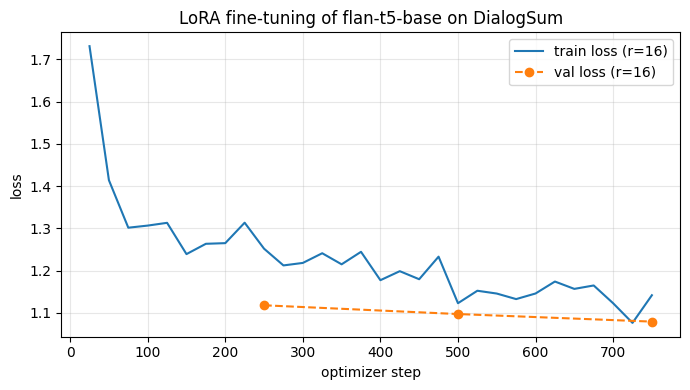

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
plt.plot(log16["step"], log16["train_loss"], label="train loss (r=16)")
steps_per_epoch = log16["step"][-1] // EPOCHS
plt.plot([steps_per_epoch * (i + 1) for i in range(EPOCHS)], log16["epoch_val_loss"], "o--", label="val loss (r=16)")
plt.xlabel("optimizer step"); plt.ylabel("loss"); plt.title("LoRA fine-tuning of flan-t5-base on DialogSum")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("outputs/loss_curve_r16.png", dpi=120); plt.show()

Save just the adapter: the LoRA A and B matrices plus the config. That's about 7 MB, compared to about 1 GB for a full copy of the model. To use it later, you load the base model and put the adapter on top, which the next cell does as a quick check.

In [12]:
ADAPTER_DIR_16 = "adapters/flan-t5-base-dialogsum-lora-r16"
lora16.save_pretrained(ADAPTER_DIR_16)
tokenizer.save_pretrained(ADAPTER_DIR_16)
for fn in sorted(os.listdir(ADAPTER_DIR_16)):
    print(f"{fn:35s} {os.path.getsize(os.path.join(ADAPTER_DIR_16, fn)) / 1e6:8.2f} MB")

README.md                               0.01 MB
adapter_config.json                     0.00 MB
adapter_model.safetensors               7.10 MB
tokenizer.json                          2.42 MB
tokenizer_config.json                   0.00 MB


In [13]:
# sanity check: reload the saved adapter on top of a fresh base model and make sure it reproduces the same output
reloaded = PeftModel.from_pretrained(AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME), ADAPTER_DIR_16).to(device)
print("reloaded == in-memory:", summarize(reloaded, demo_inputs[:1]) == summarize(lora16, demo_inputs[:1]))
del reloaded

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


reloaded == in-memory: True


## Part 5 - Post-fine-tuning inference

Same 2 test dialogues as Part 2, same greedy decoding, but now with the LoRA r=16 model.

In [14]:
ft16_outputs = summarize(lora16, demo_inputs)
for d, o in zip(demo, ft16_outputs):
    print(f"==================== {d['id']} ====================")
    print("REFERENCE      :", d["refs"][0])
    print("FINE-TUNED r=16:", o)
    print()

==================== test_0 ====================
REFERENCE      : Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.
FINE-TUNED r=16: #Person1# asks Ms. Dawson to take a dictation for #Person1#. Ms. Dawson tells #Person1# the rules of office communications and the new policy.

==================== test_1 ====================
REFERENCE      : #Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.
FINE-TUNED r=16: #Person2# got stuck in traffic again. #Person1# suggests #Person2# start taking public transport system to work. #Person2# thinks it's better for the environment and #Person2# will quit driving to work.



## Part 6 - Output comparison: before vs after fine-tuning

In [15]:
for d, b, f in zip(demo, baseline_outputs, ft16_outputs):
    print(f"==================== {d['id']} ====================")
    print("REFERENCE          :", d["refs"][0])
    print("BEFORE (base)      :", b)
    print("AFTER  (LoRA r=16) :", f)
    print()

ft16_rouge, ft16_preds = rouge_scores(lora16)
print(f"ROUGE on {N_EVAL} test dialogues")
print(f"{'model':<18}{'rouge1':>8}{'rouge2':>8}{'rougeL':>8}{'avg words':>11}")
for name, s in [("base (no FT)", baseline_rouge), ("LoRA r=16", ft16_rouge)]:
    print(f"{name:<18}{s['rouge1']:>8}{s['rouge2']:>8}{s['rougeL']:>8}{s['avg_words']:>11}")

==================== test_0 ====================
REFERENCE          : Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.
BEFORE (base)      : The memo is to be distributed to all employees by this afternoon.
AFTER  (LoRA r=16) : #Person1# asks Ms. Dawson to take a dictation for #Person1#. Ms. Dawson tells #Person1# the rules of office communications and the new policy.

==================== test_1 ====================
REFERENCE          : #Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.
BEFORE (base)      : The traffic jam at the Carrefour intersection has caused a lot of congestion.
AFTER  (LoRA r=16) : #Person2# got stuck in traffic again. #Person1# suggests #Person2# start taking public transport system to work. #Person2# thinks it's better for the environment and #Pe

### What changed

| | ROUGE-1 | ROUGE-2 | ROUGE-L | avg words |
|:--|--:|--:|--:|--:|
| base flan-t5-base (no fine-tuning) | 28.37 | 11.09 | 24.99 | 15.5 |
| LoRA r=16 | **50.38** | **24.52** | **42.34** | 21.5 |
| *human references* | | | | *19.3* |

*(all 167 test dialogues, best match of the 3 references)*

Before fine-tuning, the model basically picks one detail from the conversation and writes a single short sentence about it. For `test_0` it only mentions the memo deadline and never says the memo bans Instant Messaging. For `test_1` it only talks about the traffic jam and misses the main point, that #Person2# is convinced to stop driving. After fine-tuning, the summaries read like the DialogSum ones: they refer to people as #Person1#/#Person2#, cover the whole conversation, and for `test_1` it gets the actual outcome ("#Person2# will quit driving to work"). ROUGE-1 went from 28.4 to 50.4, and the summaries got longer (15.5 to 21.5 words), closer to the humans' 19.3.

It's still not perfect. In `test_0` it mixes up who's doing what: it says Ms. Dawson tells #Person1# the rules, when it's really #Person1# dictating the memo to her. And it only says "the new policy" without saying what the policy is.

## Part 7 - Experiment: LoRA rank r=4 vs r=16

Train a second adapter with **r=4** (alpha=8, so alpha/r is still 2). Everything else is the same as the r=16 run: same data, seed, learning rate, epochs, batch size and target modules. The only thing that changes is the rank.

While r=4 trains, I move the r=16 model to the CPU to free up GPU memory. Its outputs and scores are already saved from the cells above.

In [16]:
# park the r=16 model on the CPU while r=4 trains (its outputs/scores are already stored above)
lora16 = lora16.to("cpu"); free_memory()

lora4 = make_lora_model(r=4)
total4, trainable4 = count_params(lora4)
print(f"r=4  -> total {total4:,} | trainable {trainable4:,} ({100*trainable4/total4:.4f}%)")
print(f"r=16 -> total {total:,} | trainable {trainable:,} ({100*trainable/total:.4f}%)")

log4 = train_lora(lora4, "r=4")
ADAPTER_DIR_4 = "adapters/flan-t5-base-dialogsum-lora-r4"
lora4.save_pretrained(ADAPTER_DIR_4)

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


r=4  -> total 248,020,224 | trainable 442,368 (0.1784%)
r=16 -> total 249,347,328 | trainable 1,769,472 (0.7096%)
[r=4] val loss before training: 1.8295
[r=4] epoch 1 step   25/750 | train loss 1.8374 | lr 6.76e-04 | 42s
[r=4] epoch 1 step   50/750 | train loss 1.4676 | lr 9.82e-04 | 60s
[r=4] epoch 1 step   75/750 | train loss 1.3271 | lr 9.47e-04 | 78s
[r=4] epoch 1 step  100/750 | train loss 1.3222 | lr 9.12e-04 | 96s
[r=4] epoch 1 step  125/750 | train loss 1.3312 | lr 8.77e-04 | 115s
[r=4] epoch 1 step  150/750 | train loss 1.2549 | lr 8.42e-04 | 133s
[r=4] epoch 1 step  175/750 | train loss 1.2825 | lr 8.06e-04 | 151s
[r=4] epoch 1 step  200/750 | train loss 1.2828 | lr 7.71e-04 | 170s
[r=4] epoch 1 step  225/750 | train loss 1.3352 | lr 7.36e-04 | 189s
[r=4] epoch 1 step  250/750 | train loss 1.2751 | lr 7.01e-04 | 205s
[r=4] ---- end of epoch 1: val loss 1.1372
[r=4] epoch 2 step  275/750 | train loss 1.2474 | lr 6.66e-04 | 248s
[r=4] epoch 2 step  300/750 | train loss 1.2558 |

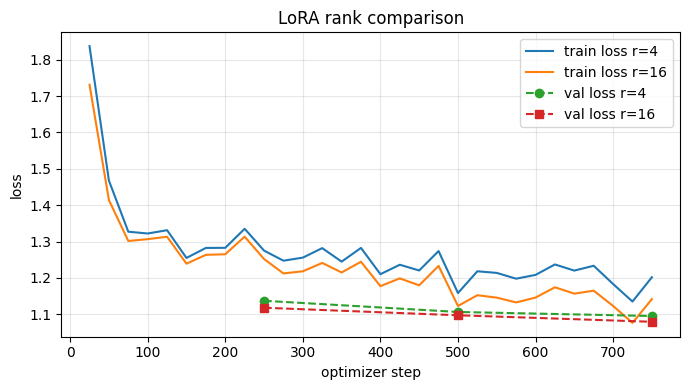

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(log4["step"], log4["train_loss"], label="train loss r=4")
plt.plot(log16["step"], log16["train_loss"], label="train loss r=16")
ep = [steps_per_epoch * (i + 1) for i in range(EPOCHS)]
plt.plot(ep, log4["epoch_val_loss"], "o--", label="val loss r=4")
plt.plot(ep, log16["epoch_val_loss"], "s--", label="val loss r=16")
plt.xlabel("optimizer step"); plt.ylabel("loss"); plt.title("LoRA rank comparison")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig("outputs/loss_curve_r4_vs_r16.png", dpi=120); plt.show()

In [18]:
ft4_outputs = summarize(lora4, demo_inputs)
for d, b, o4, o16 in zip(demo, baseline_outputs, ft4_outputs, ft16_outputs):
    print(f"==================== {d['id']} ====================")
    print("REFERENCE  :", d["refs"][0])
    print("BASE       :", b)
    print("LoRA r=4   :", o4)
    print("LoRA r=16  :", o16)
    print()

ft4_rouge, ft4_preds = rouge_scores(lora4)

rows = [
    ("base (no FT)", "-", "-", baseline_rouge, None),
    ("LoRA r=4",  f"{trainable4:,}", f"{100*trainable4/total4:.3f}%", ft4_rouge, log4),
    ("LoRA r=16", f"{trainable:,}",  f"{100*trainable/total:.3f}%",   ft16_rouge, log16),
]
print(f"{'model':<14}{'trainable':>12}{'%':>9}{'final train':>13}{'final val':>11}{'rouge1':>8}{'rouge2':>8}{'rougeL':>8}{'avg words':>11}")
for name, tp, pct, s, lg in rows:
    ftl = f"{lg['final_train_loss']:.4f}" if lg else "-"
    fvl = f"{lg['epoch_val_loss'][-1]:.4f}" if lg else "-"
    print(f"{name:<14}{tp:>12}{pct:>9}{ftl:>13}{fvl:>11}{s['rouge1']:>8}{s['rouge2']:>8}{s['rougeL']:>8}{s['avg_words']:>11}")

results = {
    "baseline": {"rouge": baseline_rouge},
    "r4":  {"trainable": trainable4, "total": total4, "log": log4, "rouge": ft4_rouge},
    "r16": {"trainable": trainable, "total": total, "log": log16, "rouge": ft16_rouge},
    "demo": [{"id": d["id"], "references": d["refs"], "baseline": b, "r4": o4, "r16": o16}
             for d, b, o4, o16 in zip(demo, baseline_outputs, ft4_outputs, ft16_outputs)],
}
with open("outputs/results.json", "w") as f:
    json.dump(results, f, indent=2)

==================== test_0 ====================
REFERENCE  : Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.
BASE       : The memo is to be distributed to all employees by this afternoon.
LoRA r=4   : Ms. Dawson tells #Person1# the new policy of using Instant Messaging in the office.
LoRA r=16  : #Person1# asks Ms. Dawson to take a dictation for #Person1#. Ms. Dawson tells #Person1# the rules of office communications and the new policy.

==================== test_1 ====================
REFERENCE  : #Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.
BASE       : The traffic jam at the Carrefour intersection has caused a lot of congestion.
LoRA r=4   : #Person2# got stuck in traffic again. #Person1# suggests #Person2# start taking public transport system to work. #Person

In [19]:
# a few extra test examples where r=4 and r=16 disagree, to look at quality beyond the 2 demo dialogues
diff = [i for i in range(N_EVAL) if ft4_preds[i] != ft16_preds[i]]
print(f"r=4 and r=16 produce different summaries on {len(diff)}/{N_EVAL} test dialogues\n")
for i in diff[:4]:
    print(f"--- {test_unique[i]['id']} ---")
    print("REF  :", eval_refs[i][0])
    print("r=4  :", ft4_preds[i])
    print("r=16 :", ft16_preds[i])
    print()

r=4 and r=16 produce different summaries on 144/167 test dialogues

--- test_0 ---
REF  : Ms. Dawson helps #Person1# to write a memo to inform every employee that they have to change the communication method and should not use Instant Messaging anymore.
r=4  : Ms. Dawson tells #Person1# the new policy of using Instant Messaging in the office.
r=16 : #Person1# asks Ms. Dawson to take a dictation for #Person1#. Ms. Dawson tells #Person1# the rules of office communications and the new policy.

--- test_1 ---
REF  : #Person2# arrives late because of traffic jam. #Person1# persuades #Person2# to use public transportations to keep healthy and to protect the environment.
r=4  : #Person2# got stuck in traffic again. #Person1# suggests #Person2# start taking public transport system to work. #Person2# feels bad about the pollution problem in this city. #Person1# recommends biking to work.
r=16 : #Person2# got stuck in traffic again. #Person1# suggests #Person2# start taking public transport syst

### How output quality changes with rank

| | r=4 | r=16 |
|:--|--:|--:|
| lora_alpha | 8 | 32 |
| trainable params | 442,368 (0.18%) | 1,769,472 (0.71%) |
| adapter file size | 1.8 MB | 7.1 MB |
| final train loss (last 25 steps) | 1.2019 | 1.1418 |
| final val loss | 1.0953 | 1.0794 |
| ROUGE-1 / ROUGE-2 / ROUGE-L | 49.50 / 23.41 / 41.32 | **50.38 / 24.52 / 42.34** |
| avg summary length | 22.5 words | 21.5 words |
| training time (T4) | 639 s | 640 s |

**r=16 was a little better on every number, but only a little.** r=4 trains 4x fewer parameters and ends up only about 1 ROUGE point behind. Its loss curves follow the r=16 ones almost exactly, just slightly higher the whole way (see the plot above). Training time was basically the same. Most of the compute goes into running the frozen 248M-parameter base model, so the adapter's size barely matters for speed.

When I read the actual summaries, I couldn't say r=16 is clearly better. The two models give different summaries on 144 of the 167 test dialogues, but a lot of that is wording, and they often start with the exact same sentence. On `test_1`, r=4 throws in more details (the pollution, biking to work) but misses how it ends, while r=16 gets the actual decision (#Person2# will quit driving). On `test_0` it goes the other way: r=4 actually mentions Instant Messaging, which is the whole point of the memo, and r=16 stays vague.

Both ranks make the same kind of mistake, and that's mixing up who said what. In `test_2` both say "Kate tells #Person2#" about the divorce, when it's #Person1# telling Kate. In `test_3` both say Brian asked #Person1# to dance, but #Person1# asked Brian. A bigger rank didn't fix this, so I'd guess it's more about the base model's size than the adapter.

**Takeaway:** for this task and a model this size, r=4 already gets almost all of the improvement over the base model (ROUGE-1 28.4 to 49.5). Going to r=16 adds about another point, for 4x the parameters and adapter size. Also, validation loss was still going down at epoch 3 for both ranks, so training longer would probably help more than raising the rank. This is one seed on 167 test dialogues, so I wouldn't read too much into a 1-point difference, but it lines up with the r=16 run's slightly lower train and val loss.

In [20]:
# bundle everything this notebook produced (adapters, loss plots, outputs JSON) into one zip - handy for downloading from Colab
import shutil
shutil.make_archive("hw5_results", "zip", ".", "outputs")
shutil.make_archive("hw5_adapters", "zip", ".", "adapters")
print([f for f in os.listdir(".") if f.endswith(".zip")])

['hw5_adapters.zip', 'hw5_results.zip']
